In [1]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

import glob
import re
import os
import warnings

In [2]:
audio_path = "../data/Experimentos"

audio_files = glob.glob(audio_path + "/*.m4a") + \
              glob.glob(audio_path + "/*.wav") + \
              glob.glob(audio_path + "/*.mp3")

print(f"Archivos de audio encontrados: {len(audio_files)}")

Archivos de audio encontrados: 56


In [3]:
def load_and_clean_audio(audio_path):
    """Carga el audio en su SR nativo y asegura que sea mono float."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y, sr = librosa.load(audio_path, sr=None)
    
    if y.ndim > 1:
        y = np.mean(y, axis=1)
    
    t = np.linspace(0, len(y) / sr, num=len(y))
    return y, sr, t

def get_initial_clusters(y, sr, t, min_peak_ratio=0.05):
    """Detecta picos y los agrupa mediante ventana dinámica."""
    amax = np.max(np.abs(y))
    threshold = amax * min_peak_ratio
    
    # 1. Detección rápida
    peaks_pos, props_pos = find_peaks(y, height=threshold)
    peaks_neg, props_neg = find_peaks(-y, height=threshold)
    
    peaks_all = np.concatenate([peaks_pos, peaks_neg])
    amps_all = np.concatenate([props_pos["peak_heights"], props_neg["peak_heights"]])
    
    # 2. Ordenamiento íntegro
    order = np.argsort(peaks_all)
    peaks_all, amps_all = peaks_all[order], amps_all[order]
    
    # 3. Agrupamiento dinámico (Este bucle es necesario por su naturaleza recursiva)
    k, beta, min_w, max_w = 0.015, 0.5, 0.004, 0.020
    clusters = []
    if len(peaks_all) == 0:
        return np.array([]), np.array([]), np.array([])

    current_cl = [0]
    for i in range(1, len(peaks_all)):
        a_cluster = np.max(amps_all[current_cl])
        win_sec = np.clip(k * (a_cluster ** beta), min_w, max_w)
        if (peaks_all[i] - peaks_all[current_cl[-1]]) <= (win_sec * sr):
            current_cl.append(i)
        else:
            clusters.append(current_cl)
            current_cl = [i]
    clusters.append(current_cl)
    
    # 4. Selección del dominante (Vectorizado donde es posible)
    dom_peaks = []
    dom_amps = []
    for cl in clusters:
        cl_arr = np.array(cl)
        m_idx = cl_arr[np.argmax(amps_all[cl_arr])]
        dom_peaks.append(peaks_all[m_idx])
        dom_amps.append(amps_all[m_idx])
        
    return np.array(dom_peaks), np.array(dom_amps), t[dom_peaks]

def apply_rhythm_filters(peaks, amps, times):
    """Aplica filtros de magnitud y de aceleración (Δt) usando NumPy puro."""
    if len(times) < 3:
        return peaks, amps, times

    # --- Filtro 1.5x (Magnitud) ---
    # Comparamos cada pico con el siguiente
    shifted_amps = np.append(amps[1:], 0)
    mask_15 = ~(amps * 1.5 < shifted_amps)
    
    p, a, t = peaks[mask_15], amps[mask_15], times[mask_15]
    
    # --- Filtro Δt (Aceleración/Ritmo) ---
    if len(t) < 3: return p, a, t
    
    dts = np.diff(t)
    dt1 = dts[:-1] # Intervalo n
    dt2 = dts[1:]  # Intervalo n+1
    
    keep = np.ones(len(t), dtype=bool)
    # Si el intervalo siguiente es más largo, descartamos el pico n+2
    keep[2:] = ~(dt2 > dt1)
    
    return p[keep], a[keep], t[keep]

def extract_dominant_peaks(audio_path):
    """Función principal modularizada."""
    y, sr, t = load_and_clean_audio(audio_path)
    
    p_dom, a_dom, t_dom = get_initial_clusters(y, sr, t)
    
    f_peaks, f_amps, f_times = apply_rhythm_filters(p_dom, a_dom, t_dom)
    
    return t, y, sr, f_peaks, f_times, f_amps


In [4]:
def compute_COR(audio_path):
    t , y, sr, _, dominant_times, _ = extract_dominant_peaks(audio_path)

    delta_t = np.diff(dominant_times)
    if len(delta_t) < 1:
        return None

    g = 9.80665
    h_n = 0.5 * g * (delta_t / 2)**2
    if len(h_n) < 2:
        return None

    ratios = np.sqrt(h_n[1:] / h_n[:-1])
    return np.mean(ratios)

def group_COR_by_experiment(folder_path, verbose=True):
    """Group COR values by experiment number 'n' from filenames like C1-{n}h-{m}.ext
    
    Args:
        folder_path: Path to folder containing audio files
        verbose: Whether to print progress messages
        
    Returns:
        Dictionary with keys as 'n' values (strings) and values as lists of COR values
    """
    COR_groups = {}
    pattern = r"C1-(\d+)h-\d+\.(m4a|wav|mp3)$"

    for fname in sorted(os.listdir(folder_path)):
        match = re.match(pattern, fname)
        if not match:
            continue

        n_value = match.group(1)  # el "n" de C1-nh-m
        audio_file_path = os.path.join(folder_path, fname)

        COR = compute_COR(audio_file_path) ###############################

        if COR is None:
            if verbose:
                print(f"{audio_file_path} → COR = None (se omite)")
            continue

        if n_value not in COR_groups:
            COR_groups[n_value] = []

        COR_groups[n_value].append(COR)

        if not verbose:
            print(f"{audio_file_path} → n={n_value} → COR = {COR}")

    if verbose:
        print("\n=== RESULTADOS AGRUPADOS POR n ===")
        for n in sorted(COR_groups, key=lambda x: int(x)):
            lista = COR_groups[n]
            print(f"n = {n} → {lista} (total {len(lista)})")
    
    return COR_groups

def plot_COR_vs_n(COR_groups):
    """Plot COR (coefficient of restitution) vs discharge time (n).
    
    Creates an error bar plot showing mean COR and standard deviation for each discharge hour.
    """
    # Convertir keys a enteros y ordenar
    ns = sorted([int(k) for k in COR_groups.keys()])

    # Obtener promedios y desviaciones estándar
    means = []
    stds  = []

    for n in ns:
        valores = np.array(COR_groups[str(n)])
        means.append(np.mean(valores))
        stds.append(np.std(valores))

    ns = np.array(ns)
    means = np.array(means)
    stds  = np.array(stds)

    plt.figure(figsize=(10,6))
    plt.errorbar(ns, means, yerr=stds, fmt='o-', capsize=6, linewidth=2)

    plt.title("COR vs discharge time (h)", fontsize=16)
    plt.xlabel("t [h]", fontsize=14)
    plt.ylabel("COR ", fontsize=14)
    plt.grid(True)
    plt.xticks(ns)
    plt.ylim(0.3, 1)  # rango típico de COR
    plt.show()

def plot_full_COR_analysis(folder_path, verbose=True):
    """Complete COR analysis pipeline: compute, group, and plot COR vs discharge time.
    
    This is the main optimized workflow that:
    1. Loads audio files only once (using group_COR_by_experiment)
    2. Computes COR values from extracted data (avoiding redundant file loading)
    3. Groups results by discharge time (n)
    4. Plots COR vs discharge time with error bars
    
    Args:
        folder_path: Path to folder containing audio files
        verbose: Whether to show progress messages during computation
        
    Returns:
        Dictionary with grouped COR values (keys are discharge times as strings)
    """
    # Step 1: Compute and group COR values (optimized - each file loaded only once)
    COR_groups = group_COR_by_experiment(folder_path, verbose=verbose) ##########################
    
    # Step 2: Plot the results
    plot_COR_vs_n(COR_groups) ########################
    
    return COR_groups


# Diccionario: clave = n (como string), valor = lista de COR de esos archivos
COR_groups = group_COR_by_experiment(audio_path)

../data/Experimentos/C1-0h-3.m4a → COR = None (se omite)

=== RESULTADOS AGRUPADOS POR n ===
n = 0 → [np.float64(0.3791360294117641), np.float64(0.3943809629767784), np.float64(0.40531289127559655), np.float64(0.39948176242099337)] (total 4)
n = 1 → [np.float64(0.4380167433005524), np.float64(0.4940048689912331), np.float64(0.44930172849848526), np.float64(0.4738755064153737), np.float64(0.48260282451299635)] (total 5)
n = 2 → [np.float64(0.5466000798969658), np.float64(0.5000471325570174), np.float64(0.48846827782434454), np.float64(0.468321477996194), np.float64(0.49322583456950353)] (total 5)
n = 3 → [np.float64(0.6095053345743147), np.float64(0.5498507168761422), np.float64(0.6113163926341416), np.float64(0.5835627428239789)] (total 4)
n = 4 → [np.float64(0.6631454189119655), np.float64(0.6670349166350049), np.float64(0.651151992495443), np.float64(0.6229209815702675)] (total 4)
n = 5 → [np.float64(0.6680984984824304), np.float64(0.6759963241714011), np.float64(0.6660750147233625)]

Analyzing: ../data/Experimentos/C1-16h-4.m4a


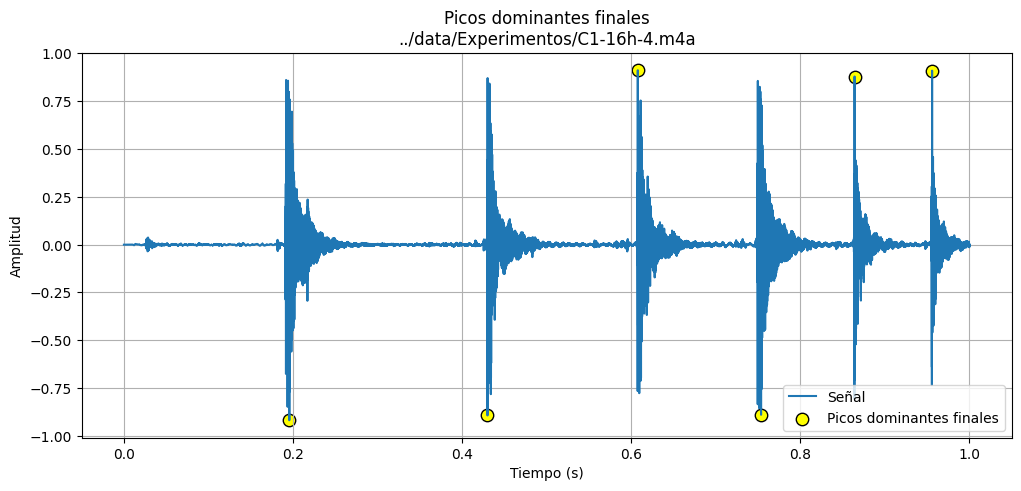

COR = 0.7895587432889417


(np.float64(0.7895587432889417),
 (array([0.00000000e+00, 2.08336463e-05, 4.16672927e-05, ...,
         1.38662500e+00, 1.38664583e+00, 1.38666667e+00], shape=(66560,)),
  array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         -1.8310547e-04, -9.1552734e-05, -9.1552734e-05],
        shape=(66560,), dtype=float32),
  48000,
  array([ 9390, 20640, 29174, 36172, 41481, 45882, 49353, 52335, 54866,
         56772, 58341, 59496, 60389, 61133, 61668, 62071]),
  array([0.19562794, 0.43000646, 0.6078008 , 0.75359466, 0.86420048,
         0.95588936, 1.02820295, 1.09032888, 1.14305884, 1.18276777,
         1.21545576, 1.23951862, 1.25812307, 1.2736233 , 1.2847693 ,
         1.29316526]),
  array([0.9178772 , 0.89294434, 0.91229248, 0.88943481, 0.87939453,
         0.90982056, 0.87918091, 0.58544922, 0.47161865, 0.36489868,
         0.32409668, 0.18490601, 0.12686157, 0.10998535, 0.0796814 ,
         0.05368042])))

In [5]:
def compute_COR_from_data(dominant_times):
    """Compute COR directly from dominant peak times (avoids reloading audio)."""
    delta_t = np.diff(dominant_times)
    if len(delta_t) < 1:
        return None

    g = 9.80665
    h_n = 0.5 * g * (delta_t / 2)**2
    if len(h_n) < 2:
        return None

    ratios = np.sqrt(h_n[1:] / h_n[:-1])
    return np.mean(ratios)


def plot_audio_peaks_from_data(t, y, sr, dom_peaks, title_suffix=""):
    """Plot peaks directly from pre-extracted data (avoids reloading audio)."""
    N_show = int(1.0 * sr)

    plt.figure(figsize=(12, 5))
    plt.plot(t[:N_show], y[:N_show], label="Señal")

    mask = dom_peaks[dom_peaks < N_show]
    plt.scatter(t[mask], y[mask],
                color="yellow", edgecolor="black", s=80,
                label="Picos dominantes finales")

    plt.title(f"Picos dominantes finales{title_suffix}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    plt.show()

# Example: Analyze and plot a specific file (both COR and peaks in one efficient call)
def analyze_and_plot_specific(n, m, plot_fft_flag=False, max_freq=5000):
    """Example: Get both COR and plot for a specific experiment without redundant loading.
    
    Args:
        plot_fft_flag: If True, also compute and plot FFT.
    """
    base = "../data/Experimentos"
    fname = f"C1-{n}h-{m}.m4a"
    audio_path = f"{base}/{fname}"
    
    print(f"Analyzing: {audio_path}")
    
    # Extract data once
    t, y, sr, peaks, times, amps = extract_dominant_peaks(audio_path)
    
    # Compute COR from extracted data
    COR = compute_COR_from_data(times)
    
    # Plot peaks from extracted data
    plot_audio_peaks_from_data(t, y, sr, peaks, f"\n{audio_path}")
    
    # Optionally compute and plot FFT
    """
    if plot_fft_flag:
        freqs, fft_amps = compute_fft_from_data(y, sr)
        plot_fft(freqs, fft_amps, max_freq=max_freq, title=f"FFT {fname}")
    """
    print(f"COR = {COR}")
    return COR, (t, y, sr, peaks, times, amps)

# Individual file analysis with both COR and plotting
analyze_and_plot_specific(16, 4)

../data/Experimentos/C1-0h-1.m4a → n=0 → COR = 0.3791360294117641
../data/Experimentos/C1-0h-2.m4a → n=0 → COR = 0.3943809629767784
../data/Experimentos/C1-0h-4.m4a → n=0 → COR = 0.40531289127559655
../data/Experimentos/C1-0h-5.m4a → n=0 → COR = 0.39948176242099337
../data/Experimentos/C1-10h-1.m4a → n=10 → COR = 0.7942002432334534
../data/Experimentos/C1-10h-2.m4a → n=10 → COR = 0.7689225140396623
../data/Experimentos/C1-10h-3.m4a → n=10 → COR = 0.778147626988212
../data/Experimentos/C1-10h-4.m4a → n=10 → COR = 0.7716494342993007
../data/Experimentos/C1-10h-5.m4a → n=10 → COR = 0.7922850202172058
../data/Experimentos/C1-13h-1.m4a → n=13 → COR = 0.7954794816529838
../data/Experimentos/C1-13h-2.m4a → n=13 → COR = 0.7766128169690074
../data/Experimentos/C1-13h-3.m4a → n=13 → COR = 0.788513604023242
../data/Experimentos/C1-13h-4.m4a → n=13 → COR = 0.7711510619771309
../data/Experimentos/C1-13h-5.m4a → n=13 → COR = 0.78280226052699
../data/Experimentos/C1-13h-6.m4a → n=13 → COR = 0.7911697

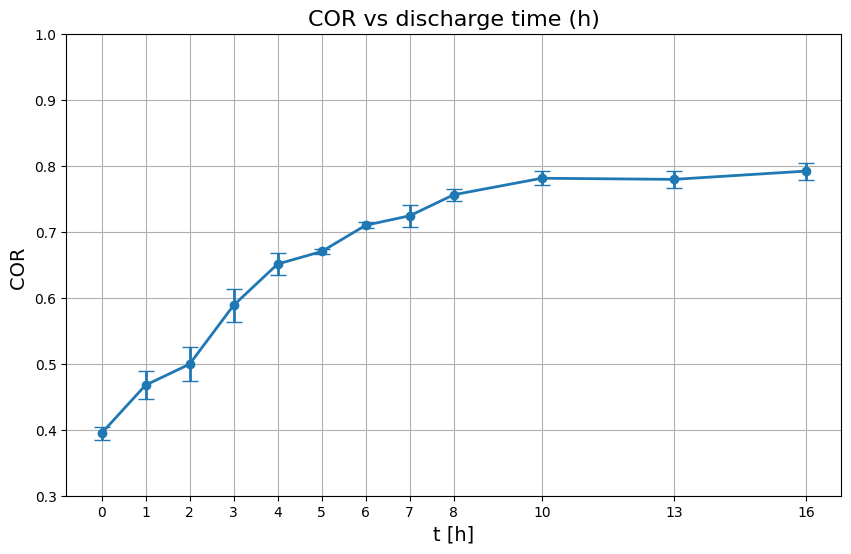

In [6]:
# Complete workflow: Compute, group, and plot COR vs discharge time
# This calls plot_full_COR_analysis which automatically:
# 1. Groups COR values by discharge time (n) using optimized group_COR_by_experiment
# 2. Plots them with plot_COR_vs_n
COR_results = plot_full_COR_analysis(audio_path, verbose=False)

In [7]:
# ==========================================================
# 1. Get specific file C1-nh-m.m4a
# ==========================================================
def get_file_path(n, m):
    base = "../data/Experimentos"
    filename = f"C1-{n}h-{m}.m4a"
    return f"{base}/{filename}"


# ==========================================================
# 2. Compute FFT
# ==========================================================
def compute_fft_from_data(y, sr, n_fft=131072):
    """
    We force all audios, without exception, to have n_fft points.
    This ensures that the frequency axis is the same for all.
    """

    # fft fill with zeros if y is shorter than n_fft
    Y = fft(y, n=n_fft)
    freqs = fftfreq(n_fft, 1/sr)

    mask = freqs >= 0
    return freqs[mask], np.abs(Y[mask])


# ==========================================================
# 3. Plot FFT
# ==========================================================
def plot_fft(freqs, amps, max_freq=7000, title="FFT", label=None):
    """Plot single FFT."""
    plt.figure(figsize=(12, 5))
    plt.plot(freqs, amps, linewidth=1, label=label)
    plt.xlim(0, max_freq)
    plt.ylim(0, np.max(amps)*1.1)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    if label:
        plt.legend()
    plt.show()
    


def plot_multiple_ffts(fft_data_list, max_freq=7000, title="FFT Comparison"):
    """Plot multiple FFTs on the same graph for comparison.
    
    Args:
        fft_data_list: List of tuples (freqs, amps, label)
    """
    plt.figure(figsize=(12, 5))
    for freqs, amps, label in fft_data_list:
        plt.plot(freqs, amps, linewidth=1, label=label)
    
    plt.xlim(0, max_freq)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


# ==========================================================
# 4. Procesar un archivo C1-nh-m y graficar su FFT
# ==========================================================
def fft_by_file_plot(n, m, max_freq=7000):
    """Process one file and plot its FFT.
    
    Args:
        n: Experiment number (discharge hour)
        m: Trial number
        max_freq: Maximum frequency to display in plot
        
    Returns:
        Tuple of (freqs, amps) for the file
    """
    # ---------- Archivo ----------
    path = get_file_path(n, m)
    y, sr, _ = load_and_clean_audio(path)
    freqs, amps = compute_fft_from_data(y, sr)
    print(f"\nArchivo: {path} (sr={sr} Hz)")

    # ---------- Plot ----------
    plot_fft(freqs, amps, max_freq=max_freq, title=f"FFT C1-{n}h-{m}")

    return freqs, amps


Archivo: ../data/Experimentos/C1-3h-2.m4a (sr=48000 Hz)


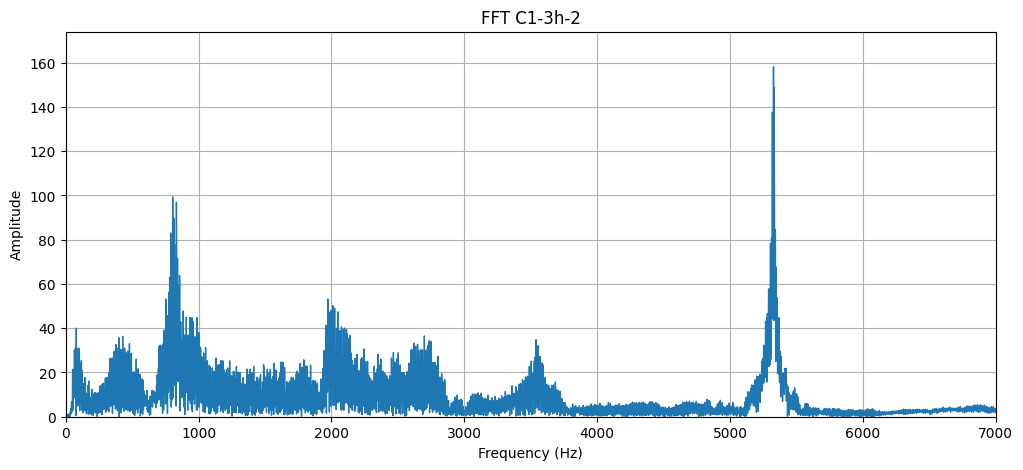

(array([0.00000000e+00, 3.66210938e-01, 7.32421875e-01, ...,
        2.39989014e+04, 2.39992676e+04, 2.39996338e+04], shape=(65536,)),
 array([0.33337402, 0.50848716, 0.602443  , ..., 0.00135635, 0.00079896,
        0.00063133], shape=(65536,), dtype=float32))

In [8]:
# Plot two files separately
# h1 - try1 - h2 - try2
fft_by_file_plot(3, 2)

# N = len(y) data
# (1/5 out) 1h-1 : N=49152
# (3/3 out) 5h-2: N=46080; -3: N=49152; -4: N=50176
# (4/4 out) 7h-2: N=54272; -3: N=50175; -4: N=49152; -5: N=55296
# (1/5 out) 8h-1: N=56320
# (5/5 out) 10h-1: N=50176; -2: N=54272; -3: N=60416; -4: N=52224; -5: N=60416
# (8/8 out) 13h-1: N=56320; -2: N=55296; -3: N=62464; -4: N=55296; -5: N=54272; -6: N=60416; -7: N=50176; -8: N=50176
# (5/5 out) 16h-1: N=59392; -2: N=61440; -3: N=57344; -4: N=66569; -5: N=64512

In [9]:
def get_average_fft_for_hour(hour, attempts, plot=False, n_fft=131072, max_freq=7000, filter_savgol=False):
    """Compute (and plot) average FFT for a given discharge hour (n) by averaging all its trials (m).
    
    Args:
        hour: Discharge hour
        attempts: List of trial numbers
        plot: Whether to plot the average FFT
        n_fft: Number of FFT points
        max_freq: Maximum frequency to display in plot
        filter_savgol: Whether to apply Savitzky-Golay filter

    Returns:
        Tuple of (freqs, avg_magnitude)
    """
    all_magnitudes = []
    sr_ref = None

    for m in attempts:
        path = get_file_path(hour, m)
        try:
            # Load audio with warnings suppressed
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                y, sr = librosa.load(path, sr=None) # load at native SR
            sr_ref = sr  
            
            # LOCAL NORMALIZATION: Before averaging, we equalize energies
            y_norm = y / np.sqrt(np.mean(y**2))
            
            # compute FFT for N points (same for all)
            f, mag = compute_fft_from_data(y_norm, sr, n_fft=n_fft)
            if filter_savgol:
                mag = savgol_filter(mag, 51, 3)  # Apply Savitzky-Golay filter
            all_magnitudes.append(mag)
            
        except Exception as e:
            print(f"Error cargando {path}: {e}")

    # Mean magnitude across attempts for each frequency bin
    avg_magnitude = np.mean(all_magnitudes, axis=0)
    
    # ---------- Plot ----------
    if plot:
        plot_fft(f, avg_magnitude, max_freq=max_freq, title=f"FFT C1-{hour}h, mean of {len(attempts)} attempts")
        pass

    return f, avg_magnitude

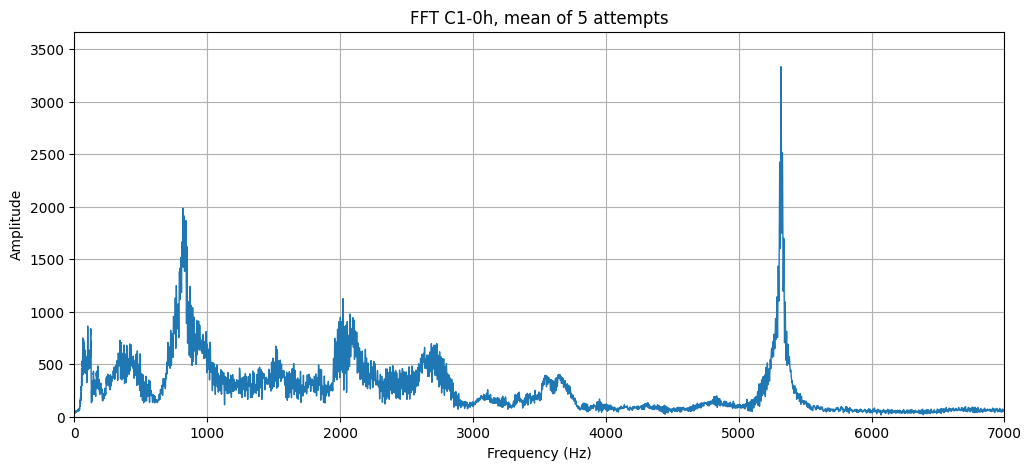

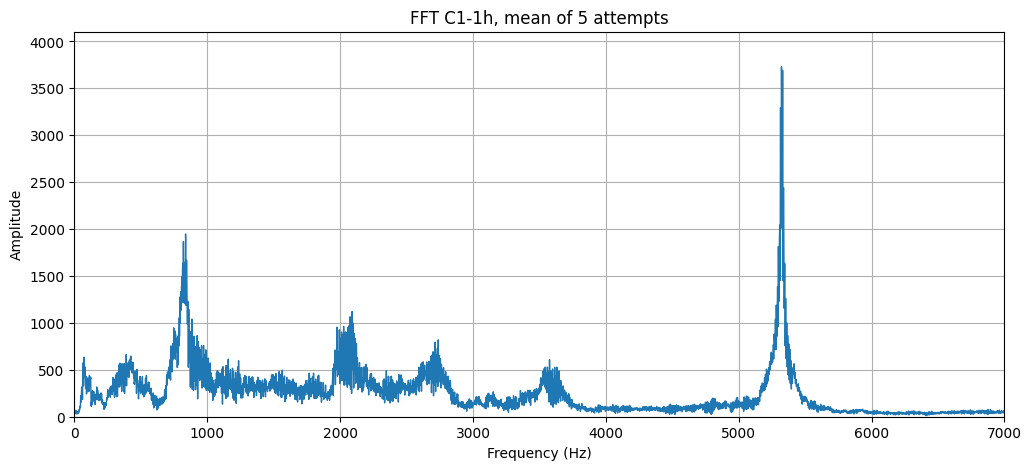

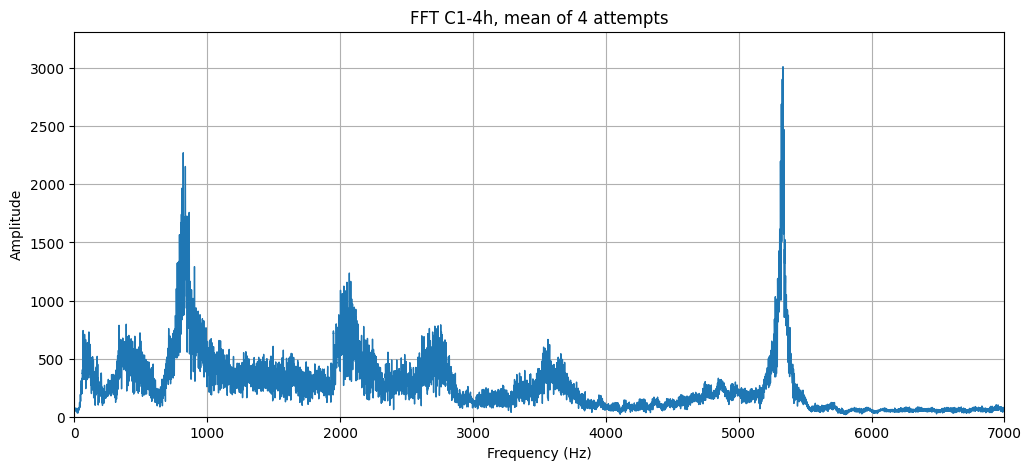

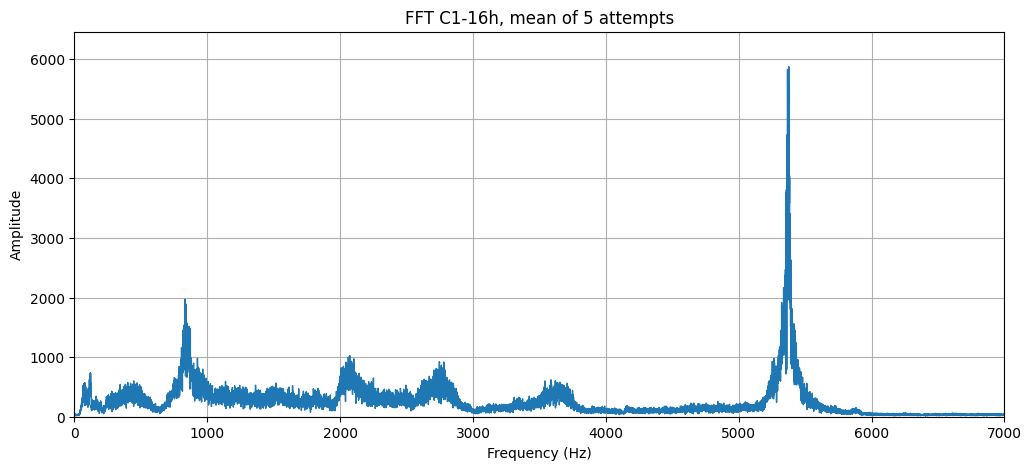

(array([0.00000000e+00, 3.66210938e-01, 7.32421875e-01, ...,
        2.39989014e+04, 2.39992676e+04, 2.39996338e+04], shape=(65536,)),
 array([5.4159142e+01, 4.9789513e+01, 4.0682312e+01, ..., 3.3168346e-02,
        3.5553697e-02, 3.7571687e-02], shape=(65536,), dtype=float32))

In [10]:
get_average_fft_for_hour(0, [1, 2, 3, 4, 5], plot=True)
get_average_fft_for_hour(1, [1, 2, 3, 4, 5], plot=True)
get_average_fft_for_hour(4, [1, 2, 4, 5], plot=True)
get_average_fft_for_hour(16, [1, 2, 3, 4, 5], plot=True)

In [15]:
def plot_hour_comparison(hours_list, attempts_dict, max_freq=7000, filter_savgol=False):
    """
    Compara los espectros promedio de varias horas en una sola gráfica.
    hours_list: [0, 8, 16]
    attempts_dict: {0: [1,2,3,4], 8: [1,2,3], 16: [1,2,3,4,5]}
    """
    plt.figure(figsize=(10, 6))
    
    for h in hours_list:
        f, mag_avg = get_average_fft_for_hour(h, attempts_dict[h])
        
        if filter_savgol:
            # Window_length must be odd and less than the length of avg_mag.
            # A value between 51 and 101 is often a good compromise.
            mag_avg = savgol_filter(mag_avg, window_length=76, polyorder=3)
        
        plt.plot(f, mag_avg, label=f"Descarga: {h} horas")
    
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Amplitud Normalizada localmente")
    plt.title("Evolución del Espectro de Frecuencias según Estado de Carga")
    plt.legend()
    plt.xlim(0, max_freq) # Limitar a la zona de interés (ej. 5kHz)
    plt.ylim(0, np.max(mag_avg)*1.1) # Ajustar límite superior para mejor visualización
    plt.show()

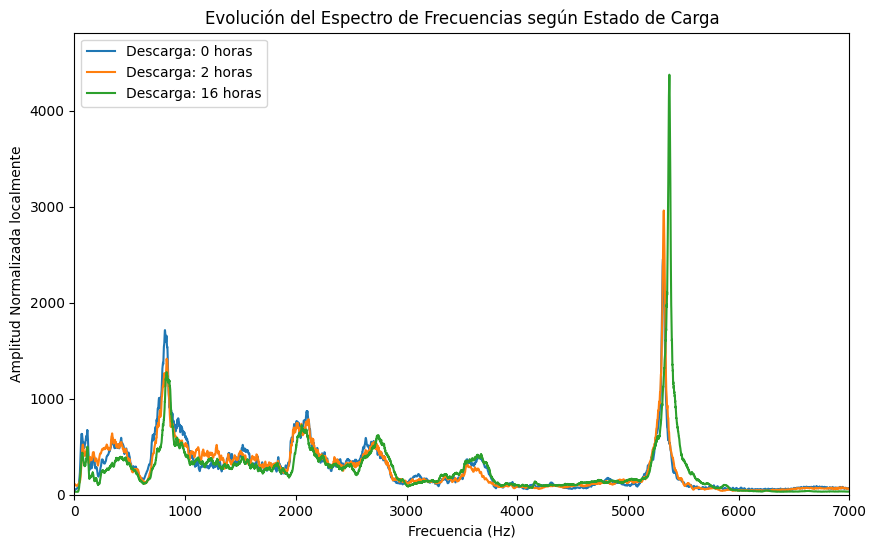

In [16]:
#plot_hour_comparison([0, 2, 4, 8, 16],
# {0: [1,2,3,4], 2:[1,2,3,4,5], 4:[1,2,4,5], 8: [1,2,3], 16: [1,2,3,4,5],}, filter_savgol=True)

plot_hour_comparison([0, 2, 16],
{0: [1,2,3,4], 2:[1,2,3,4,5], 16: [1,2,3,4,5],}, filter_savgol=True)

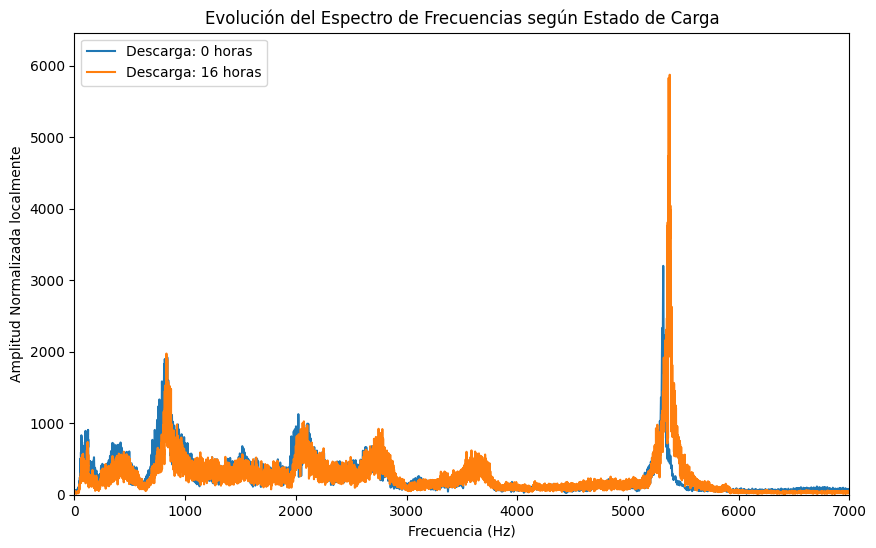

In [17]:
plot_hour_comparison([0,16],
{0: [1,2,3,4], 2:[1,2,3,4,5], 16: [1,2,3,4,5],}, filter_savgol=False)

In [22]:
# Let's try to fit a lorentzian to the important peak
# In order to compute Q and compare with Q via FWHM
def lorentzian(f, f_res, gamma, A, offset):
    """
    Mathematical model for the Cauchy-Lorentz distribution.
    f_res: Resonance frequency (peak center).
    gamma: Scale parameter (HWHM - Half Width at Half Maximum).
    A: Amplitude scaling factor.
    offset: Vertical shift to account for noise floor.
    """
    return (A / np.pi) * (gamma / ((f - f_res)**2 + gamma**2)) + offset

def analyze_resonance_peak(freqs, magnitudes, f_min=5300, f_max=5395): # adjust f_min and f_max based on observed peak locations
    """
    Performs ROI cropping, manual FWHM estimation, and Lorentzian fitting.
    Inputs should be the smoothed/filtered spectrum for better convergence.
    """
    # 1. ROI Cropping
    mask = (freqs >= f_min) & (freqs <= f_max)
    f_roi = freqs[mask]
    m_roi = magnitudes[mask]
    
    # --- METHOD A: MANUAL CALCULATION (FWHM) ---
    # Find absolute peak in the ROI
    idx_max = np.argmax(m_roi)
    f_res_man = f_roi[idx_max]
    a_max_man = m_roi[idx_max]
    
    # Threshold for FWHM (approx -3dB point in magnitude)
    target = a_max_man / np.sqrt(2)
    
    try:
        # Find f1 (left of peak) and f2 (right of peak)
        f1 = f_roi[:idx_max][np.argmin(np.abs(m_roi[:idx_max] - target))]
        f2 = f_roi[idx_max:][np.argmin(np.abs(m_roi[idx_max:] - target))]
        fwhm_man = f2 - f1
        q_manual = f_res_man / fwhm_man
    except Exception:
        q_manual = np.nan

    # --- METHOD B: LORENTZIAN FITTING ---
    # Initial guesses (p0) to ensure the optimizer converges correctly
    # Estimated gamma from manual FWHM (gamma = FWHM/2)
    init_gamma = 20 if np.isnan(q_manual) else fwhm_man / 2
    p0 = [f_res_man, init_gamma, a_max_man * np.pi * init_gamma, np.min(m_roi)]
    
    try:
        popt, _ = curve_fit(lorentzian, f_roi, m_roi, p0=p0)
        f_res_fit, gamma_fit, A_fit, offset_fit = popt
        
        fwhm_fit = 2 * gamma_fit
        q_fit = f_res_fit / fwhm_fit
    except RuntimeError:
        print("Optimization failed. Check initial guesses or data noise.")
        return None

    return {
        "f_roi": f_roi, 
        "m_roi": m_roi,
        "popt": popt,
        "q_manual": q_manual, 
        "q_fit": q_fit,
        "f_res_fit": f_res_fit, 
        "fwhm_fit": fwhm_fit
    }

def analyze_resonance_peak_adaptive(freqs, magnitudes, f_width_guess=100):
    """
    Finds the peak and applies an adaptive ROI based on the estimated FWHM
    to ensure the Lorentzian fit focuses on the peak regardless of the discharge state.
    """
    # 1. Initial broad search to locate the peak
    search_mask = (freqs >= 5100) & (freqs <= 5600)
    if not np.any(search_mask): return None
    
    f_search = freqs[search_mask]
    m_search = magnitudes[search_mask]
    
    idx_max_global = np.argmax(m_search)
    f_center = f_search[idx_max_global]
    a_max = m_search[idx_max_global]
    
    # 2. Adaptive Window Logic:
    # First, we estimate the FWHM manually to define the new ROI
    target = a_max / np.sqrt(2)
    try:
        # Local search for FWHM points
        f1 = f_search[:idx_max_global][np.argmin(np.abs(m_search[:idx_max_global] - target))]
        f2 = f_search[idx_max_global:][np.argmin(np.abs(m_search[idx_max_global:] - target))]
        est_fwhm = f2 - f1
    except:
        est_fwhm = f_width_guess # Fallback if noise is too high

    # 3. Define the Adaptive ROI
    # We take N times the estimated FWHM to capture the "shoulders" but not the noise floor
    # A multiplier of 2.5 to 3.5 is usually ideal for Lorentzians
    multiplier = 3.0
    f_min = f_center - (multiplier * est_fwhm)
    f_max = f_center + (multiplier * est_fwhm)
    
    roi_mask = (freqs >= f_min) & (freqs <= f_max)
    f_roi = freqs[roi_mask]
    m_roi = magnitudes[roi_mask]
    
    # 4. Weighted Lorentzian Fitting
    # Giving more weight to points near the peak amplitude
    weights = 1.0 / (np.abs(m_roi - a_max) + 1.0)
    
    p0 = [f_center, est_fwhm/2, a_max * np.pi * (est_fwhm/2), np.min(m_roi)]
    
    try:
        popt, _ = curve_fit(lorentzian, f_roi, m_roi, p0=p0, sigma=weights)
        f_res_fit, gamma_fit, A_fit, offset_fit = popt
        
        q_fit = f_res_fit / (2 * gamma_fit)
        
        return {
            "f_roi": f_roi, "m_roi": m_roi, "popt": popt,
            "q_fit": q_fit, "f_res": f_res_fit, "est_fwhm": est_fwhm
        }
    except Exception as e:
        print(f"Fit failed at {f_center:.1f} Hz: {e}")
        return None

--- RESULTADOS 1 HORAS ---
Q Manual: 271.67
Q Ajuste: 203.21
Frecuencia Resonancia: 5372.95 Hz


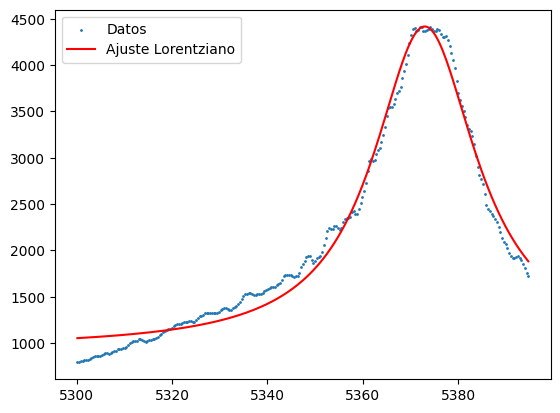


--- RESULTADOS 1 HORAS (Dynamic ROI) ---
Q Ajuste: 149.35
Frecuencia Resonancia: 5370.47 Hz


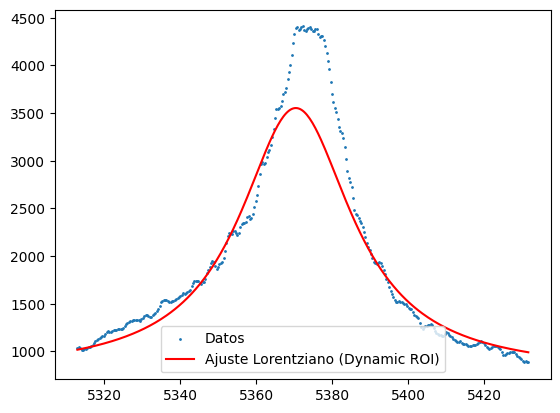

In [25]:
# Ejemplo para la batería de 16h
f_repr_16h, mag_repr_16h = get_average_fft_for_hour(16, [1, 2, 3, 4, 5], plot=False, filter_savgol=True)
res_16h = analyze_resonance_peak(f_repr_16h, mag_repr_16h)
res_16h_dynamic = analyze_resonance_peak_adaptive(f_repr_16h, mag_repr_16h)

print(f"--- RESULTADOS 1 HORAS ---")
print(f"Q Manual: {res_16h['q_manual']:.2f}")
print(f"Q Ajuste: {res_16h['q_fit']:.2f}")
print(f"Frecuencia Resonancia: {res_16h['f_res_fit']:.2f} Hz")

# Visualización del ajuste
plt.scatter(res_16h['f_roi'], res_16h['m_roi'], s=1, label='Datos')
plt.plot(res_16h['f_roi'], lorentzian(res_16h['f_roi'], *res_16h['popt']), 
         'r-', label='Ajuste Lorentziano')
plt.legend()
plt.show()


print(f"\n--- RESULTADOS 1 HORAS (Dynamic ROI) ---")
print(f"Q Ajuste: {res_16h_dynamic['q_fit']:.2f}")
print(f"Frecuencia Resonancia: {res_16h_dynamic['f_res']:.2f} Hz")

# Visualización del ajuste dinámico
plt.scatter(res_16h_dynamic['f_roi'], res_16h_dynamic['m_roi'], s=1, label='Datos')
plt.plot(res_16h_dynamic['f_roi'], lorentzian(res_16h_dynamic['f_roi'], *res_16h_dynamic['popt']), 
         'r-', label='Ajuste Lorentziano (Dynamic ROI)')
plt.legend()
plt.show()

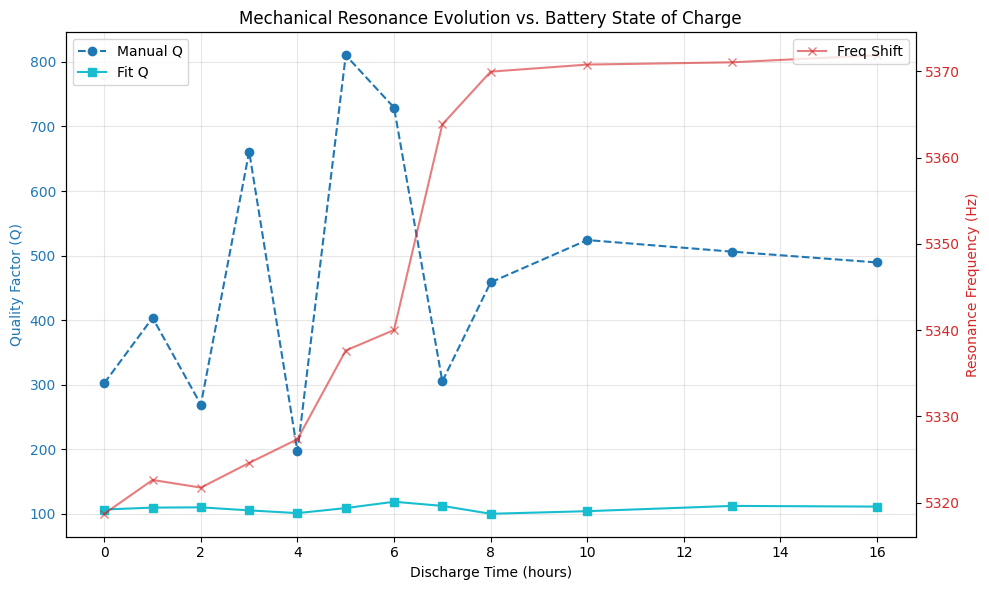

In [26]:
# Now let's see the evolution of Q (fit and manual) across discharge times (n)
def run_full_analysis(hours_list, attempts_dict, fs=44100):
    """
    Iterates through all discharge hours, calculates both Q values,
    and stores them for comparison.
    """
    results_list = []

    for h in hours_list:
        # 1. Get the refined (averaged + smoothed) spectrum for the hour
        # This uses the functions we built previously
        f, mag_avg = get_average_fft_for_hour(h, attempts_dict[h])
        
        # 2. Analyze the resonance peak at ~5.4 kHz
        analysis = analyze_resonance_peak(f, mag_avg, f_min=5000, f_max=5800)
        
        if analysis:
            results_list.append({
                "hour": h,
                "q_manual": analysis["q_manual"],
                "q_fit": analysis["q_fit"],
                "f_res": analysis["f_res_fit"]
            })
    
    return pd.DataFrame(results_list)

# Execution
hours = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 13, 16]
attempts_dict = {
    0: [1, 2, 3, 4, 5],
    1: [1, 2, 3, 4, 5],
    2: [1, 2, 3, 4, 5],
    3: [1, 2, 3, 5],
    4: [1, 2, 4, 5],
    5: [2, 3, 4],
    6: [2, 4, 5],
    7: [2, 3, 4, 5], 
    8: [1, 2, 3, 4, 5],
    10: [1, 2, 3, 4, 5],
    13: [1, 2, 3, 4, 5, 6, 7, 8],
    16: [1, 2, 3, 4, 5]
}
df_results = run_full_analysis(hours, attempts_dict)

# --- Plotting the comparison ---
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Discharge Time (hours)')
ax1.set_ylabel('Quality Factor (Q)', color='tab:blue')
ax1.plot(df_results['hour'], df_results['q_manual'], 'o--', label='Manual Q', color='tab:blue')
ax1.plot(df_results['hour'], df_results['q_fit'], 's-', label='Fit Q', color='tab:cyan')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Create a second axis for the Resonance Frequency Shift
ax2 = ax1.twinx()
ax2.set_ylabel('Resonance Frequency (Hz)', color='tab:red')
ax2.plot(df_results['hour'], df_results['f_res'], 'x-', color='tab:red', label='Freq Shift', alpha=0.6)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Mechanical Resonance Evolution vs. Battery State of Charge')
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()